In [1]:
import google
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# scGPT

## Introduction


For scGPT model weight, we use the `scGPT_human` model to provide embeddings out of the box. You may download it from [here](https://drive.google.com/drive/folders/1oWh_-ZRdhtoGQ2Fw24HP41FgLoomVo-y).



In [ ]:
!source /content/drive/MyDrive/gp/scgpt/gpt_env/bin/activate;

In [2]:
# Specifically for Google Colab, install dependencies and download data

import os
import sys

if "google.colab" in sys.modules:
    print("Running on Google Colab")
    print("Installing dependencies...")
    !pip install -U scgpt "torch<=2.2.2" "numpy<2" "umap-learn<0.5.7"
    # the optional dependency of flash-attion is skipped on colab
    !pip install wandb louvain

  # NOTE: MAY NEED TO RESTART RUNTIME AFTER THE INSTALLATION


Running on Google Colab
Installing dependencies...
ERROR: Operation cancelled by user


KeyboardInterrupt: 

## Import scGPT and dependencies

In [1]:
!pip install anndata scanpy scib muon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.4/174.4 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 105.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.7/293.7 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 144.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 110.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 113.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2

In [ ]:
from pathlib import Path
import warnings
import os
import muon
import scanpy as sc
import scib
import numpy as np
import sys

sys.path.insert(0, "../")

# import scgpt as scg
import matplotlib.pyplot as plt
import anndata

plt.style.context('default')
warnings.simplefilter("ignore", ResourceWarning)
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


model_dir = Path("/content/drive/MyDrive/gp/scgpt/save/scGPT_human")
data_dir = "/content/drive/MyDrive/gp/datasets"

/usr/local/lib/python3.12/dist-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


## Imports for regression model

In [19]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr, spearmanr
import numpy as np


# Bone Marrow dataset Protein Expression Prediction

## Prepare the datasets

In [ ]:
rna_data_path = os.path.join(data_dir, "GP_datasets/BoneMarrow/Bonemarrow_rna.h5ad")
adata = sc.read_h5ad(rna_data_path)
adata


AnnData object with n_obs × n_vars = 20000 × 13953
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [8]:
adt_data_path = os.path.join(data_dir, "GP_datasets/BoneMarrow/Bonemarrow_adt.h5ad")
adata_adt = sc.read_h5ad(adt_data_path)
adata_adt


AnnData object with n_obs × n_vars = 20000 × 134
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'clr', 'counts'

In [ ]:
adata_adt.X = adata_adt.layers["counts"].copy()
muon.prot.pp.clr(adata_adt)
adata_adt.layers["clr"] = adata_adt.X.copy()

In [ ]:
adata_adt

AnnData object with n_obs × n_vars = 20000 × 134
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts', 'clr'

In [ ]:
adata.var.index

Index(['AL627309.5', 'LINC01409', 'LINC01128', 'LINC00115', 'FAM41C', 'NOC2L',
       'KLHL17', 'HES4', 'ISG15', 'AGRN',
       ...
       'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5', 'MT-ND6', 'MT-CYB',
       'AC011043.1', 'AL592183.1', 'AC240274.1', 'AC007325.4'],
      dtype='object', length=13953)

In [ ]:
adata.var['gene_symbols'] = adata.var_names

In [ ]:
adata.X = adata.layers['counts'].copy()

In [ ]:
adata

AnnData object with n_obs × n_vars = 20000 × 13953
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id', 'id_in_vocab', 'gene_symbols'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [ ]:
gene_col = "gene_symbols"

In [ ]:
adata.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 29062742 stored elements and shape (20000, 13953)>

## Generate the cell embeddings

Now we will generate the cell embeddings for the dataset using `embed_data` function. `embed_data` calculates the cell embedding for each cell with the given scGPT model. The extracted embedding is stored in the `X_scGPT` field of `obsm` in AnnData.

In [ ]:
embed_adata = scg.tasks.embed_data(
    adata,
    model_dir,
    gene_col=gene_col,
    batch_size=64,
)
# attach the cell embedding to the original adata

scGPT - INFO - match 12587/12587 genes in vocabulary of size 60697.


/usr/local/lib/python3.12/dist-packages/scgpt/model/model.py:77: UserWarning: flash-attn is not installed, using pytorch transformer instead. Set use_fast_transformer=False to avoid this warning. Installing flash-attn is highly recommended.
  warnings.warn(
Embedding cells: 100%|██████████| 313/313 [03:14<00:00,  1.61it/s]
/usr/local/lib/python3.12/dist-packages/scgpt/tasks/cell_emb.py:279: ImplicitModificationWarning: Setting element `.obsm['X_scGPT']` of view, initializing view as actual.
  adata.obsm["X_scGPT"] = cell_embeddings


In [ ]:
embed_adata

AnnData object with n_obs × n_vars = 20000 × 12587
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id', 'id_in_vocab', 'gene_symbols'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap', 'X_scGPT'
    layers: 'counts'

In [ ]:
embed_adata.write("/content/drive/MyDrive/gp/data/datasets/scgpt_embedded/bonemarrow_scgpt_embedded.h5ad")

## Regression

In [5]:
adata = sc.read_h5ad(os.path.join(data_dir, "datasets/scgpt_embedded/bonemarrow_scgpt_embedded.h5ad"))
adata_adt = sc.read_h5ad(os.path.join(data_dir, "GP_datasets/BoneMarrow/Bonemarrow_adt.h5ad"))

In [6]:
adata

AnnData object with n_obs × n_vars = 20000 × 12587
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id', 'id_in_vocab', 'gene_symbols'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap', 'X_scGPT'
    layers: 'counts'

In [9]:
adata_adt

AnnData object with n_obs × n_vars = 20000 × 134
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'clr', 'counts'

In [10]:
X = adata.obsm['X_scGPT']
y=adata_adt.layers['clr']

X = X.toarray() if hasattr(X, "toarray") else X
y = y.toarray() if hasattr(y, "toarray") else y

In [28]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()
mse_scores = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

In [31]:
# per-protein MSE
mse_per_protein = ((y_test - y_pred) ** 2).mean(axis=0)

# overall mean
avg_mse = mse_per_protein.mean()

print("Avg MSE:", avg_mse)
print("Per-protein MSE:", mse_per_protein)
print("Per-protein MSE shape:", mse_per_protein.shape)

Avg MSE: 0.20006889
Per-protein MSE: [0.20688917 0.20931849 0.10538936 0.14078903 0.12670049 0.18351056
 0.17997165 0.14304952 0.11100128 0.21670009 0.2190775  0.5068077
 0.21665592 0.18320087 0.24120063 0.25008193 0.25026613 0.29080874
 0.2108644  0.32917216 0.11836331 0.18648948 0.21301094 0.33577982
 0.24263437 0.17008524 0.2457879  0.20011532 0.2284226  0.12627436
 0.16244283 0.20060498 0.13806455 0.2961397  0.12672058 0.20311621
 0.26595995 0.25123492 0.15617183 0.26588082 0.29697594 0.1538505
 0.2187053  0.23687135 0.37354767 0.20462158 0.11669424 0.13528544
 0.29627833 0.2425133  0.15387222 0.11542788 0.12977555 0.27938727
 0.22131626 0.20433453 0.17547992 0.1077581  0.13523111 0.15399821
 0.27592665 0.16610228 0.16690023 0.14456603 0.14971851 0.26075882
 0.10684816 0.15643995 0.22306927 0.23815873 0.13917387 0.22699718
 0.1562546  0.25677773 0.19963893 0.16071407 0.2227224  0.2148928
 0.12179969 0.16796985 0.150691   0.14660984 0.16494723 0.3542924
 0.12607117 0.1289089  0.0987

In [29]:
# per-protein MSE and rMSE
mse_per_protein = ((y_test - y_pred) ** 2).mean(axis=0)
rmse_per_protein = np.sqrt(mse_per_protein)

# overall mean
avg_mse = mse_per_protein.mean()
avg_rmse = rmse_per_protein.mean()


In [30]:
print("Avg MSE:", avg_mse)
# print("Per-protein MSE:", mse_per_protein)
# print("Per-protein MSE shape:", mse_per_protein.shape)


print("Avg RMSE:", avg_rmse)
# print("Per-protein RMSE:", rmse_per_protein)
# print("Per-protein RMSE shape:", rmse_per_protein.shape)

Avg MSE: 0.20006889
Avg RMSE: 0.44139886


In [32]:
pearson_per_protein = []

for i in range(y_test.shape[1]):
    if np.std(y_test[:, i]) > 0 and np.std(y_pred[:, i]) > 0:
        corr, _ = pearsonr(y_test[:, i], y_pred[:, i])
    else:
        corr = np.nan
    pearson_per_protein.append(corr)

pearson_per_protein = np.array(pearson_per_protein)
mean_pearson = np.nanmean(pearson_per_protein)

spearman_per_protein = []

for i in range(y_test.shape[1]):
    if np.std(y_test[:, i]) > 0 and np.std(y_pred[:, i]) > 0:
        corr, _ = spearmanr(y_test[:, i], y_pred[:, i])
    else:
        corr = np.nan
    spearman_per_protein.append(corr)

spearman_per_protein = np.array(spearman_per_protein)
mean_spearman = np.nanmean(spearman_per_protein)

In [33]:
print("Avg Pearson correlation:", mean_pearson)
# print("Per-protein Pearson correlation:", pearson_per_protein)
# print("Per-protein Pearson shape:", pearson_per_protein.shape)

print("Mean Spearman correlation:", mean_spearman)
# print("Per-protein Spearman correlation:", spearman_per_protein)
# print("Per-protein Spearman shape:", spearman_per_protein.shape)

Avg Pearson correlation: 0.7275516
Mean Spearman correlation: 0.6402160174790564


In [24]:
valid_idx = np.where(~np.isnan(pearson_per_protein))[0]
valid_scores = pearson_per_protein[valid_idx]

sorted_idx = valid_idx[np.argsort(valid_scores)]

worst_idx = sorted_idx[0]
median_idx = sorted_idx[len(sorted_idx)//2]
best_idx = sorted_idx[-1]

selected_idx = [worst_idx, median_idx, best_idx]
labels = ["Worst", "Median", "Best"]

protein_names = np.array(adata_adt.var_names)

print("\nSelected proteins:")
for label, idx in zip(labels, selected_idx):
    print(
        f"{label}: {protein_names[idx]} "
        f"(Pearson = {pearson_per_protein[idx]:.4f})"
    )


Selected proteins:
Worst: TCRVd2 (Pearson = 0.3073)
Median: CD226 (Pearson = 0.7633)
Best: CD71 (Pearson = 0.9288)


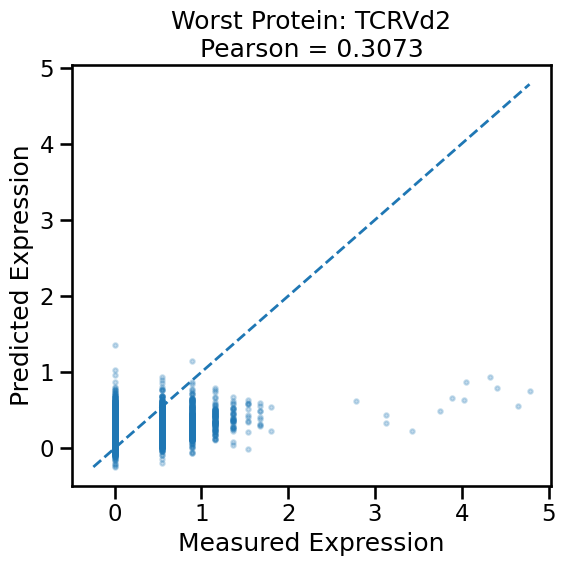

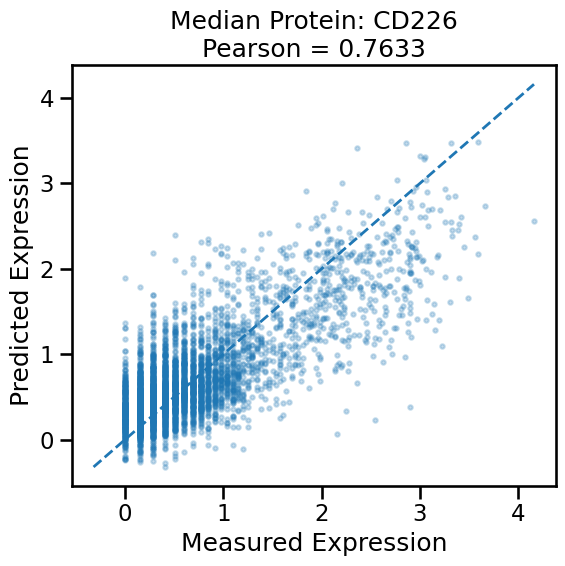

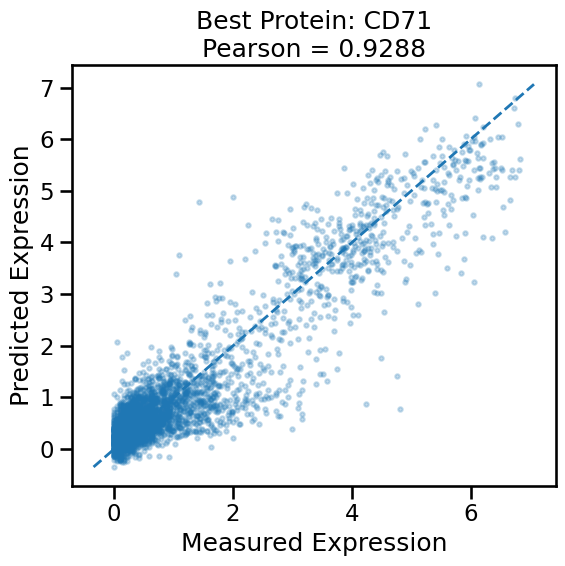

In [25]:
for label, idx in zip(labels, selected_idx):

    x = y_test[:, idx]
    yhat = y_pred[:, idx]

    plt.figure(figsize=(6,6))

    plt.scatter(
        x,
        yhat,
        s=10,
        alpha=0.25
    )

    mn = min(x.min(), yhat.min())
    mx = max(x.max(), yhat.max())

    plt.plot([mn, mx], [mn, mx], "--", linewidth=2)

    plt.xlabel("Measured Expression")
    plt.ylabel("Predicted Expression")

    plt.title(
        f"{label} Protein: {protein_names[idx]}\n"
        f"Pearson = {pearson_per_protein[idx]:.4f}"
    )

    plt.tight_layout()
    plt.show()

In [35]:
from pathlib import Path
import numpy as np

save_path = Path("/content/drive/MyDrive/gp/data/GP_datasets/results")
save_path.mkdir(parents=True, exist_ok=True)

model_name = "scGPT"  # change per notebook

np.savez(
    save_path / f"{model_name}_BM_protein_results.npz", # change dataset name

    # raw outputs
    y_test=y_test,
    y_pred=y_pred,

    # metadata
    protein_names=protein_names,

    # metrics
    pearson_per_protein=pearson_per_protein,

    # selected indices (diagnostic)
    worst_idx=worst_idx,
    median_idx=median_idx,
    best_idx=best_idx,

    selected_idx=np.array(selected_idx),

    mean_pearson=np.nanmean(pearson_per_protein),
)

print(f"Saved results for {model_name} at:", save_path)

Saved results for scGPT at: /content/drive/MyDrive/gp/data/GP_datasets/results


# CBMC dataset Protein Expression Prediction

## Prepare the datasets

In [ ]:
rna_data_path = os.path.join(data_dir, "CBMC/cbmc_rna_filtered.h5ad")
adata = sc.read_h5ad(rna_data_path)
adata


AnnData object with n_obs × n_vars = 8617 × 19626
    obs: 'size_factors'
    var: 'n_counts', 'feature_name', 'hvg', 'hvg_score', 'gene_symbols'
    uns: '_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id', 'var_names_all'
    obsm: 'X_svd', 'mode2'
    layers: 'counts', 'normalized'

In [ ]:
adt_data_path = os.path.join(data_dir, "CBMC/cbmc_adt.h5ad")
adata_adt = sc.read_h5ad(adt_data_path)
adata_adt


AnnData object with n_obs × n_vars = 8617 × 13
    var: 'feature_name', 'hvg', 'hvg_score'
    uns: 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id'
    obsm: 'X_svd'
    layers: 'counts', 'normalized'

In [ ]:
adata.var.index

Index(['HUMAN_A1BG', 'HUMAN_A1BG-AS1', 'HUMAN_A1CF', 'HUMAN_A2M',
       'HUMAN_A2M-AS1', 'HUMAN_A2ML1', 'HUMAN_A4GALT', 'HUMAN_A4GNT',
       'HUMAN_AAAS', 'HUMAN_AACS',
       ...
       'HUMAN_ZW10', 'HUMAN_ZWILCH', 'HUMAN_ZWINT', 'HUMAN_ZXDA', 'HUMAN_ZXDB',
       'HUMAN_ZXDC', 'HUMAN_ZYG11B', 'HUMAN_ZYX', 'HUMAN_ZZEF1', 'HUMAN_ZZZ3'],
      dtype='string', length=19626)

In [ ]:
adata

AnnData object with n_obs × n_vars = 8617 × 19626
    obs: 'size_factors'
    var: 'n_counts', 'feature_name', 'hvg', 'hvg_score', 'gene_symbols'
    uns: '_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id', 'var_names_all'
    obsm: 'X_svd', 'mode2'
    layers: 'counts', 'normalized'

In [ ]:
gene_col = "gene_symbols"

In [ ]:
adata

View of AnnData object with n_obs × n_vars = 8617 × 3000
    obs: 'size_factors'
    var: 'n_counts', 'feature_name', 'hvg', 'hvg_score', 'gene_symbols', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: '_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id', 'var_names_all', 'hvg'
    obsm: 'X_svd', 'mode2'
    layers: 'counts', 'normalized'

## Generate the cell embeddings

Now we will generate the cell embeddings for the dataset using `embed_data` function. `embed_data` calculates the cell embedding for each cell with the given scGPT model. The extracted embedding is stored in the `X_scGPT` field of `obsm` in AnnData.

In [ ]:
embed_adata = scg.tasks.embed_data(
    adata,
    model_dir,
    gene_col=gene_col,
    batch_size=64,
)
# attach the cell embedding to the original adata

scGPT - INFO - match 14908/19626 genes in vocabulary of size 60697.


/usr/local/lib/python3.12/dist-packages/scgpt/model/model.py:77: UserWarning: flash-attn is not installed, using pytorch transformer instead. Set use_fast_transformer=False to avoid this warning. Installing flash-attn is highly recommended.
  warnings.warn(
Embedding cells: 100%|██████████| 135/135 [01:33<00:00,  1.44it/s]
/usr/local/lib/python3.12/dist-packages/scgpt/tasks/cell_emb.py:279: ImplicitModificationWarning: Setting element `.obsm['X_scGPT']` of view, initializing view as actual.
  adata.obsm["X_scGPT"] = cell_embeddings


In [ ]:
embed_adata

AnnData object with n_obs × n_vars = 8617 × 2576
    obs: 'size_factors'
    var: 'n_counts', 'feature_name', 'hvg', 'hvg_score', 'gene_symbols', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'id_in_vocab'
    uns: '_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id', 'var_names_all', 'hvg'
    obsm: 'X_svd', 'mode2', 'X_scGPT'
    layers: 'counts', 'normalized'

In [ ]:
embed_adata.write("/content/drive/MyDrive/gp/data/datasets/scgpt_embedded/cbmc_scgpt_embedded.h5ad")

## Regression

In [38]:
adata = sc.read_h5ad(os.path.join(data_dir, "datasets/scgpt_embedded/cbmc_scgpt_embedded.h5ad"))
adata_adt = sc.read_h5ad(os.path.join(data_dir, "GP_datasets/CBMC/cbmc_adt.h5ad"))

In [39]:
adata

AnnData object with n_obs × n_vars = 8617 × 14908
    obs: 'size_factors'
    var: 'n_counts', 'feature_name', 'hvg', 'hvg_score', 'gene_symbols', 'id_in_vocab'
    uns: '_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id', 'var_names_all'
    obsm: 'X_scGPT', 'X_svd', 'mode2'
    layers: 'counts', 'normalized'

In [40]:
adata_adt

AnnData object with n_obs × n_vars = 8617 × 13
    var: 'feature_name', 'hvg', 'hvg_score'
    uns: 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id'
    obsm: 'X_svd'
    layers: 'counts', 'normalized'

In [41]:
X = adata.obsm['X_scGPT']
y=adata_adt.layers['normalized']

X = X.toarray() if hasattr(X, "toarray") else X
y = y.toarray() if hasattr(y, "toarray") else y

In [42]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()
mse_scores = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

In [44]:
# per-protein MSE and rMSE
mse_per_protein = ((y_test - y_pred) ** 2).mean(axis=0)
rmse_per_protein = np.sqrt(mse_per_protein)

# overall mean
avg_mse = mse_per_protein.mean()
avg_rmse = rmse_per_protein.mean()


In [46]:
pearson_per_protein = []

for i in range(y_test.shape[1]):
    if np.std(y_test[:, i]) > 0 and np.std(y_pred[:, i]) > 0:
        corr, _ = pearsonr(y_test[:, i], y_pred[:, i])
    else:
        corr = np.nan
    pearson_per_protein.append(corr)

pearson_per_protein = np.array(pearson_per_protein)
mean_pearson = np.nanmean(pearson_per_protein)

spearman_per_protein = []

for i in range(y_test.shape[1]):
    if np.std(y_test[:, i]) > 0 and np.std(y_pred[:, i]) > 0:
        corr, _ = spearmanr(y_test[:, i], y_pred[:, i])
    else:
        corr = np.nan
    spearman_per_protein.append(corr)

spearman_per_protein = np.array(spearman_per_protein)
mean_spearman = np.nanmean(spearman_per_protein)

In [43]:
# per-protein MSE
mse_per_protein = ((y_test - y_pred) ** 2).mean(axis=0)

# overall mean
avg_mse = mse_per_protein.mean()

print("Avg MSE:", avg_mse)
print("Per-protein MSE:", mse_per_protein)
print("Per-protein MSE shape:", mse_per_protein.shape)

Avg MSE: 0.118912585
Per-protein MSE: [0.08579133 0.11250374 0.560725   0.10094289 0.11286052 0.07455623
 0.07388985 0.0821254  0.06650894 0.06523134 0.07811809 0.07128952
 0.06132093]
Per-protein MSE shape: (13,)


In [45]:
print("Avg MSE:", avg_mse)
# print("Per-protein MSE:", mse_per_protein)
# print("Per-protein MSE shape:", mse_per_protein.shape)


print("Avg RMSE:", avg_rmse)
# print("Per-protein RMSE:", rmse_per_protein)
# print("Per-protein RMSE shape:", rmse_per_protein.shape)

Avg MSE: 0.118912585
Avg RMSE: 0.32074407


In [47]:
print("Avg Pearson correlation:", mean_pearson)
# print("Per-protein Pearson correlation:", pearson_per_protein)
# print("Per-protein Pearson shape:", pearson_per_protein.shape)

print("Mean Spearman correlation:", mean_spearman)
# print("Per-protein Spearman correlation:", spearman_per_protein)
# print("Per-protein Spearman shape:", spearman_per_protein.shape)

Avg Pearson correlation: 0.75965697
Mean Spearman correlation: 0.6407259836711732


In [48]:
valid_idx = np.where(~np.isnan(pearson_per_protein))[0]
valid_scores = pearson_per_protein[valid_idx]

sorted_idx = valid_idx[np.argsort(valid_scores)]

worst_idx = sorted_idx[0]
median_idx = sorted_idx[len(sorted_idx)//2]
best_idx = sorted_idx[-1]

selected_idx = [worst_idx, median_idx, best_idx]
labels = ["Worst", "Median", "Best"]

protein_names = np.array(adata_adt.var_names)

print("\nSelected proteins:")
for label, idx in zip(labels, selected_idx):
    print(
        f"{label}: {protein_names[idx]} "
        f"(Pearson = {pearson_per_protein[idx]:.4f})"
    )


Selected proteins:
Worst: CCR7 (Pearson = 0.5006)
Median: CD14 (Pearson = 0.8128)
Best: CD3 (Pearson = 0.9412)


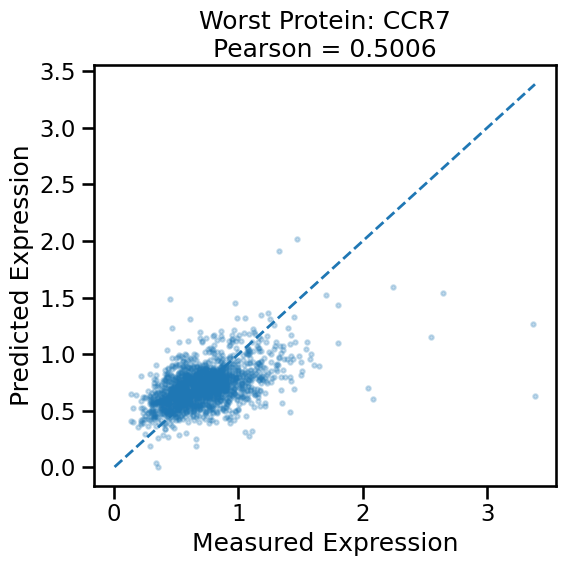

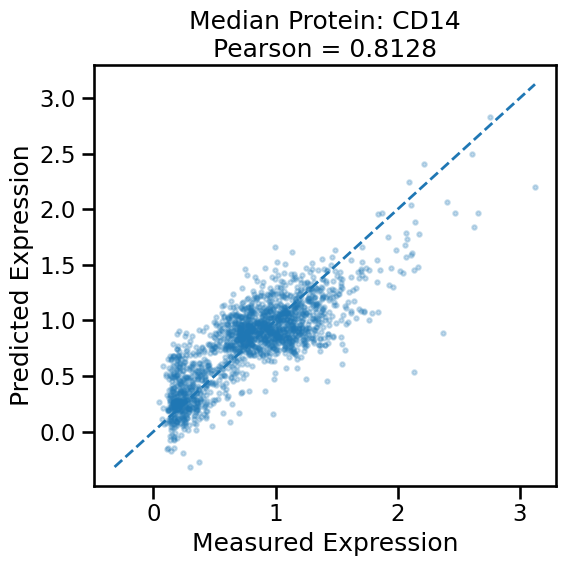

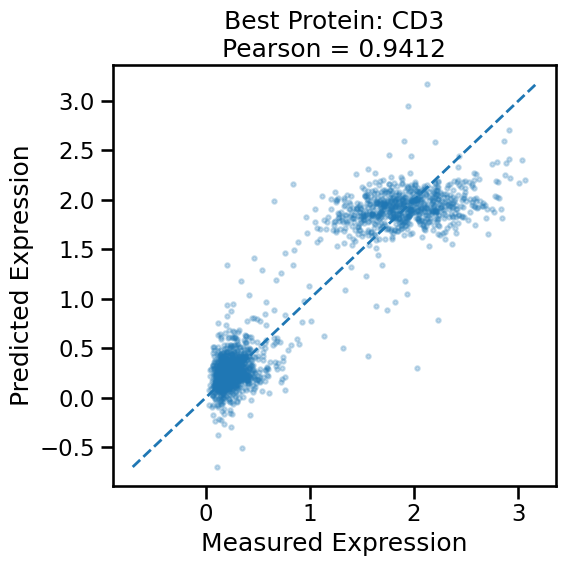

In [49]:
for label, idx in zip(labels, selected_idx):

    x = y_test[:, idx]
    yhat = y_pred[:, idx]

    plt.figure(figsize=(6,6))

    plt.scatter(
        x,
        yhat,
        s=10,
        alpha=0.25
    )

    mn = min(x.min(), yhat.min())
    mx = max(x.max(), yhat.max())

    plt.plot([mn, mx], [mn, mx], "--", linewidth=2)

    plt.xlabel("Measured Expression")
    plt.ylabel("Predicted Expression")

    plt.title(
        f"{label} Protein: {protein_names[idx]}\n"
        f"Pearson = {pearson_per_protein[idx]:.4f}"
    )

    plt.tight_layout()
    plt.show()

In [50]:
from pathlib import Path
import numpy as np

save_path = Path("/content/drive/MyDrive/gp/data/GP_datasets/results")
save_path.mkdir(parents=True, exist_ok=True)

model_name = "scGPT"  # change per notebook

np.savez(
    save_path / f"{model_name}_CBMCs_protein_results.npz", # change dataset name

    # raw outputs
    y_test=y_test,
    y_pred=y_pred,

    # metadata
    protein_names=protein_names,

    # metrics
    pearson_per_protein=pearson_per_protein,

    # selected indices (diagnostic)
    worst_idx=worst_idx,
    median_idx=median_idx,
    best_idx=best_idx,

    selected_idx=np.array(selected_idx),

    mean_pearson=np.nanmean(pearson_per_protein),
)

print(f"Saved results for {model_name} at:", save_path)

Saved results for scGPT at: /content/drive/MyDrive/gp/data/GP_datasets/results
